# Notebook 02 — Pulizia Dati e Analisi SQL
**Capstone: Aree Interne Italiane** 


In [1]:
import os
os.chdir(r'C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2')
print("Working directory:", os.getcwd())

Working directory: C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE_2


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "data/processed/"
OUTPUT_DIR    = "outputs/"
DB_PATH       = "sql/aree_interne.db"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("sql", exist_ok=True)
print("Percorsi configurati OK")

Percorsi configurati OK


In [3]:
df = pd.read_csv(PROCESSED_DIR + "comuni_master.csv", dtype={"codice_comune": str})
print(f"Righe: {len(df)} | Colonne: {list(df.columns)}")
df.head()

Righe: 7894 | Colonne: ['Codice Regione', 'provincia', 'Codice Provincia (Storico)(1)', 'Progressivo del Comune (2)', 'codice_comune', 'Denominazione (Italiana e straniera)', 'comune', 'Denominazione altra lingua', 'cod_ripartizione', 'ripartizione', 'regione', "Denominazione dell'Unità territoriale sovracomunale \n(valida a fini statistici)", 'Tipologia di Unità territoriale sovracomunale ', 'capoluogo', 'sigla_prov', 'Codice Comune formato numerico', 'Codice Comune numerico con 107 Province (dal 2017 al 2025)', 'Codice Comune numerico con 110 Province (dal 2010 al 2016)', 'Codice Comune numerico con 107 Province (dal 2006 al 2009)', 'Codice Comune numerico con 103 Province (dal 1995 al 2005)', 'Codice Catastale del Comune', 'Codice NUTS1 2021', 'Codice NUTS2 2021 (3) ', 'Codice NUTS3 2021', 'Codice NUTS1 2024', 'Codice NUTS2 2024 (3) ', 'Codice NUTS3 2024', 'classe_snai', 'desc_snai', 'classe_snai_old', 'desc_snai_old', 'is_area_interna']


,Codice Regione,provincia,Codice Provincia (Storico)(1),Progressivo del Comune (2),codice_comune,Denominazione (Italiana e straniera),comune,Denominazione altra lingua,cod_ripartizione,ripartizione,...,Codice NUTS2 2021 (3),Codice NUTS3 2021,Codice NUTS1 2024,Codice NUTS2 2024 (3),Codice NUTS3 2024,classe_snai,desc_snai,classe_snai_old,desc_snai_old,is_area_interna
0,1,201,1,1,001001,Agliè,Agliè,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,C,C - Cintura,C,C - Cintura,0
1,1,201,1,2,001002,Airasca,Airasca,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,C,C - Cintura,C,C - Cintura,0
2,1,201,1,3,001003,Ala di Stura,Ala di Stura,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,E,E - Periferico,E,E - Periferico,1
3,1,201,1,4,001004,Albiano d'Ivrea,Albiano d'Ivrea,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,C,C - Cintura,C,C - Cintura,0
4,1,201,1,6,001006,Almese,Almese,NaN,1,Nord-ovest,...,ITC1,ITC11,ITC,ITC1,ITC11,C,C - Cintura,C,C - Cintura,0


## 1. Pulizia e Arricchimento Dati
Aggiungiamo due colonne derivate:
- **`tipo_area`**: etichetta testuale leggibile per la classificazione SNAI
- **`macro_area`**: raggruppamento geografico semplificato (Nord / Centro / Sud e Isole)

In [4]:
def tipo_area(classe):
    mapping = {
        "A": "Polo",
        "B": "Polo Intercomunale",
        "C": "Cintura",
        "D": "Intermedio",
        "E": "Periferico",
        "F": "Ultraperiferico"
    }
    return mapping.get(str(classe).strip().upper(), "Non classificato")

macro_map = {
    "Nord-ovest": "Nord",
    "Nord-est":   "Nord",
    "Centro":     "Centro",
    "Sud":        "Sud e Isole",
    "Isole":      "Sud e Isole"
}

df["tipo_area"]  = df["classe_snai"].apply(tipo_area)
df["macro_area"] = df["ripartizione"].map(macro_map)

print(df[["codice_comune","comune","classe_snai","tipo_area","macro_area"]].head(10))

  codice_comune           comune classe_snai           tipo_area macro_area
0        001001            Agliè           C             Cintura       Nord
1        001002          Airasca           C             Cintura       Nord
2        001003     Ala di Stura           E          Periferico       Nord
3        001004  Albiano d'Ivrea           C             Cintura       Nord
4        001006           Almese           C             Cintura       Nord
5        001007          Alpette           E          Periferico       Nord
6        001008        Alpignano           B  Polo Intercomunale       Nord
7        001009         Andezeno           C             Cintura       Nord
8        001010          Andrate           C             Cintura       Nord
9        001011         Angrogna           D          Intermedio       Nord


In [5]:
df.to_csv(PROCESSED_DIR + "comuni_master_clean.csv", index=False)
print("Salvato: comuni_master_clean.csv")
print("Distribuzione tipo_area:")
print(df["tipo_area"].value_counts())

Salvato: comuni_master_clean.csv
Distribuzione tipo_area:
tipo_area
Cintura               3710
Intermedio            1821
Periferico            1412
Non classificato       387
Ultraperiferico        331
Polo                   176
Polo Intercomunale      57
Name: count, dtype: int64


## 2. Creazione Database SQLite
Creo il database `aree_interne.db` con la tabella `comuni`.

In [6]:
conn = sqlite3.connect(DB_PATH)

col_want = ["codice_comune","comune","regione","provincia","ripartizione",
            "macro_area","sigla_prov","capoluogo","classe_snai","tipo_area","is_area_interna"]
col_db = [c for c in col_want if c in df.columns]
col_miss = [c for c in col_want if c not in df.columns]
if col_miss:
    print(f"Colonne assenti (ignorate): {col_miss}")

df_db = df[col_db].copy()
# Salviamo nel DB (to_sql crea la tabella automaticamente con le colonne disponibili)
df_db.to_sql("comuni", conn, if_exists="replace", index=False)

n = pd.read_sql("SELECT COUNT(*) as n FROM comuni", conn).iloc[0,0]
print(f"Tabella comuni creata: {n} righe | Colonne: {col_db}")

Tabella comuni creata: 7894 righe | Colonne: ['codice_comune', 'comune', 'regione', 'provincia', 'ripartizione', 'macro_area', 'sigla_prov', 'capoluogo', 'classe_snai', 'tipo_area', 'is_area_interna']


## 3. Query SQL Analitiche
### Query 1 — Percentuale Aree Interne per Regione (Top 10)

                     regione  totale_comuni  comuni_aree_interne  perc_aree_interne
                  Basilicata            131                  119               90.8
                     Sicilia            391                  310               79.3
Trentino-Alto Adige/Südtirol            282                  218               77.3
                      Molise            136                  104               76.5
                    Calabria            404                  280               69.3
                     Abruzzo            305                  202               66.2
                     Toscana            273                  164               60.1
                      Puglia            257                  148               57.6
                       Lazio            378                  215               56.9
Valle d'Aosta/Vallée d'Aoste             74                   41               55.4


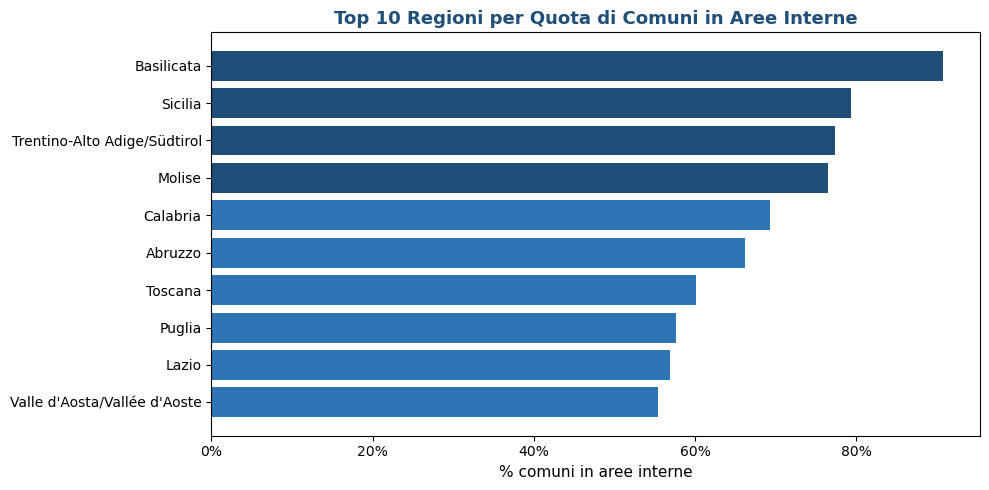

In [7]:
q1 = """
SELECT
    regione,
    COUNT(*) AS totale_comuni,
    SUM(is_area_interna) AS comuni_aree_interne,
    ROUND(100.0 * SUM(is_area_interna) / COUNT(*), 1) AS perc_aree_interne
FROM comuni
GROUP BY regione
ORDER BY perc_aree_interne DESC
LIMIT 10
"""

df_q1 = pd.read_sql(q1, conn)
print(df_q1.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1F4E79" if x >= 70 else "#2E75B6" if x >= 50 else "#9DC3E6"
          for x in df_q1["perc_aree_interne"]]
ax.barh(df_q1["regione"], df_q1["perc_aree_interne"], color=colors)
ax.set_xlabel("% comuni in aree interne", fontsize=11)
ax.set_title("Top 10 Regioni per Quota di Comuni in Aree Interne",
             fontsize=13, fontweight="bold", color="#1F4E79")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Query 2 — Confronto Nord / Centro / Sud e Isole

 macro_area       tipo_area  num_comuni
     Centro      Intermedio         319
     Centro      Periferico         190
     Centro Ultraperiferico          21
       Nord      Intermedio         873
       Nord      Periferico         576
       Nord Ultraperiferico         132
Sud e Isole      Intermedio         629
Sud e Isole      Periferico         646
Sud e Isole Ultraperiferico         178


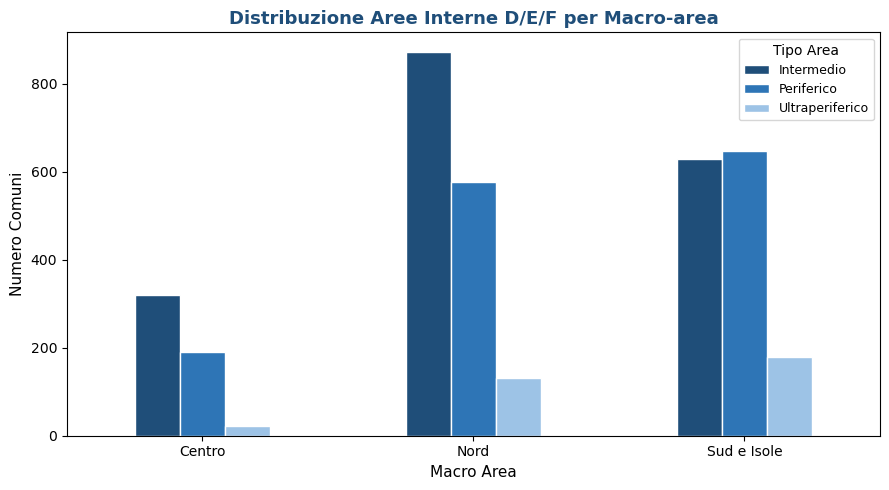

In [8]:
q2 = """
SELECT
    macro_area,
    tipo_area,
    COUNT(*) AS num_comuni
FROM comuni
WHERE classe_snai IN ('D', 'E', 'F')
GROUP BY macro_area, tipo_area
ORDER BY macro_area, tipo_area
"""

df_q2 = pd.read_sql(q2, conn)
print(df_q2.to_string(index=False))

pivot2 = df_q2.pivot(index="macro_area", columns="tipo_area", values="num_comuni").fillna(0)
pivot2.plot(kind="bar", figsize=(9, 5),
            color=["#1F4E79","#2E75B6","#9DC3E6"], edgecolor="white")
plt.title("Distribuzione Aree Interne D/E/F per Macro-area",
          fontsize=13, fontweight="bold", color="#1F4E79")
plt.xlabel("Macro Area", fontsize=11)
plt.ylabel("Numero Comuni", fontsize=11)
plt.xticks(rotation=0)
plt.legend(title="Tipo Area", fontsize=9)
plt.tight_layout()
plt.show()

### Query 3 — Comuni Ultraperiferici (F) per Regione

                     regione  comuni_ultraperiferici
                  Basilicata                      44
                    Campania                      42
                   Lombardia                      41
Trentino-Alto Adige/Südtirol                      36
                     Sicilia                      34
                     Abruzzo                      33
                    Piemonte                      18
              Emilia-Romagna                      18
                     Toscana                      17
                    Calabria                      13
                      Veneto                       7
                     Liguria                       7
                      Puglia                       6
                      Molise                       6
       Friuli-Venezia Giulia                       5
                       Lazio                       3
                      Marche                       1


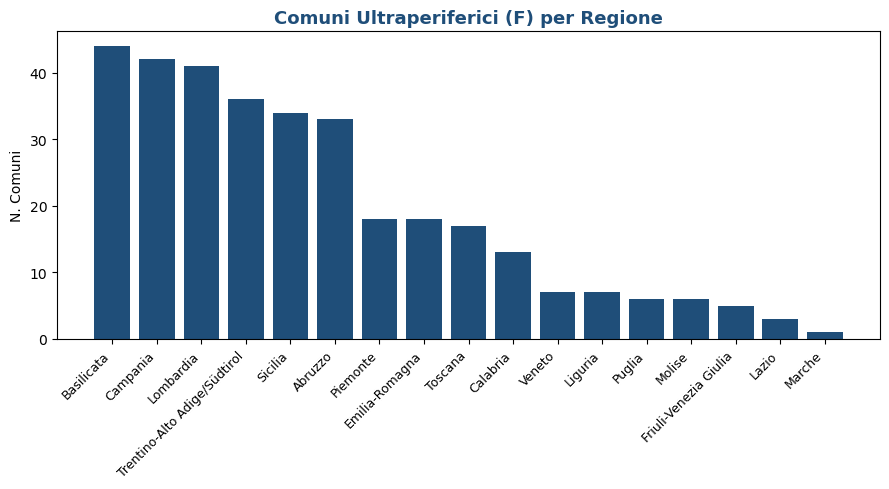

In [9]:
q3 = """
SELECT regione, COUNT(*) AS comuni_ultraperiferici
FROM comuni
WHERE classe_snai = 'F'
GROUP BY regione
ORDER BY comuni_ultraperiferici DESC
"""

df_q3 = pd.read_sql(q3, conn)
print(df_q3.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(df_q3["regione"], df_q3["comuni_ultraperiferici"], color="#1F4E79")
ax.set_title("Comuni Ultraperiferici (F) per Regione",
             fontsize=13, fontweight="bold", color="#1F4E79")
ax.set_ylabel("N. Comuni")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

### Query 4 — Capoluoghi di Provincia in Aree Interne

In [10]:
q4 = """
SELECT comune, regione, provincia, classe_snai, tipo_area
FROM comuni
WHERE capoluogo = 1 AND is_area_interna = 1
ORDER BY regione, tipo_area
"""

df_q4 = pd.read_sql(q4, conn)
print(f"Capoluoghi in aree interne: {len(df_q4)}")
print(df_q4.to_string(index=False))

Capoluoghi in aree interne: 0
Empty DataFrame
Columns: [comune, regione, provincia, classe_snai, tipo_area]
Index: []


In [11]:
conn.close()
print("Connessione SQLite chiusa.")

Connessione SQLite chiusa.
